#Clustering

# ===============================================
# 📌 1. Importación de librerías necesarias
# ===============================================

In [40]:
# ---------------------------------------------------------------
# 📦 Importar librerías para manejo y análisis de datos
# ---------------------------------------------------------------

import pandas as pd   # Pandas: se usa para manipular, limpiar y analizar datos estructurados (tablas tipo Excel o CSV)
import numpy as np    # NumPy: se usa para operaciones numéricas y manejo de arreglos multidimensionales

# ---------------------------------------------------------------
# 📊 Librerías para visualización (gráficos)
# ---------------------------------------------------------------

import matplotlib.pyplot as plt   # Matplotlib: permite crear gráficos básicos (líneas, barras, dispersión, etc.)
import seaborn as sns             # Seaborn: librería construida sobre Matplotlib que crea gráficos estadísticos más atractivos y con menos código

# ---------------------------------------------------------------
# 🤖 Librerías de Machine Learning (scikit-learn)
# ---------------------------------------------------------------

from sklearn.cluster import KMeans               # Algoritmo de agrupamiento (clustering) no supervisado, agrupa datos en K grupos
from sklearn.model_selection import train_test_split  # Divide los datos en conjuntos de entrenamiento y prueba
from sklearn.preprocessing import StandardScaler      # Escala los datos para que todas las variables tengan media 0 y desviación estándar 1
from sklearn.metrics import silhouette_score          # Mide qué tan bien definidos están los clusters (calidad del agrupamiento)
from sklearn.decomposition import PCA                 # Análisis de Componentes Principales: reduce la dimensionalidad de los datos para visualización o simplificación

# ---------------------------------------------------------------
# 🎨 Configurar el estilo de los gráficos
# ---------------------------------------------------------------
sns.set(style="whitegrid")   # Define un estilo visual limpio con fondo blanco y líneas de cuadrícula (ideal para análisis de datos)

# ---------------------------------------------------------------
# 🎲 Fijar semilla aleatoria
# ---------------------------------------------------------------
np.random.seed(42)
# Establece una semilla para el generador de números aleatorios de NumPy.
# Esto garantiza que los resultados (por ejemplo, los grupos del KMeans o muestras aleatorias)
# sean reproducibles: si ejecutas el código otra vez, obtendrás el mismo resultado.

# ---------------------------------------------------------------
# ✅ Confirmación de carga correcta
# ---------------------------------------------------------------
print("✅ Librerías importadas correctamente.")
# Imprime un mensaje indicando que todas las librerías se importaron sin errores.


✅ Librerías importadas correctamente.


# ===============================================
# 📌 2. Carga del dataset
# ===============================================

In [41]:
# Usamos el dataset "Mall Customers" con datos de clientes
# Puedes subir el archivo a Colab con el botón "Subir archivo"
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers (1).csv


📋 Columnas del dataset

| Columna                  | Tipo       | Descripción                                                                              |
| ------------------------ | ---------- | ---------------------------------------------------------------------------------------- |
| `CustomerID`             | Numérica   | Identificador único del cliente (solo sirve como referencia, no para análisis).          |
| `Gender`                 | Categórica | Género del cliente: `"Male"` o `"Female"`.                                               |
| `Age`                    | Numérica   | Edad del cliente, en años.                                                               |
| `Annual Income (k$)`     | Numérica   | Ingreso anual estimado del cliente, en miles de dólares (por ejemplo, 60 = \$60,000).    |
| `Spending Score (1-100)` | Numérica   | Puntuación otorgada por el sistema del mall, basada en los hábitos de gasto del cliente. |


In [42]:
# Leer el archivo CSV subido
df = pd.read_csv("Mall_Customers.csv")
df.head(10) #Muestra las 5 priemras columnas del dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


# ===============================================
# 📌 3. Análisis exploratorio inicial
# ===============================================

In [43]:
# Información general del DataFrame
print("\nInformación general del DataFrame:")
print(df.info())


Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [44]:
# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())


Estadísticas descriptivas:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000


In [45]:
# Conteo de valores únicos en columnas categóricas (si las hay)
print("\nConteo de valores únicos en 'Gender':")
print(df['Genre'].value_counts())


Conteo de valores únicos en 'Gender':
Genre
Female    112
Male       88
Name: count, dtype: int64


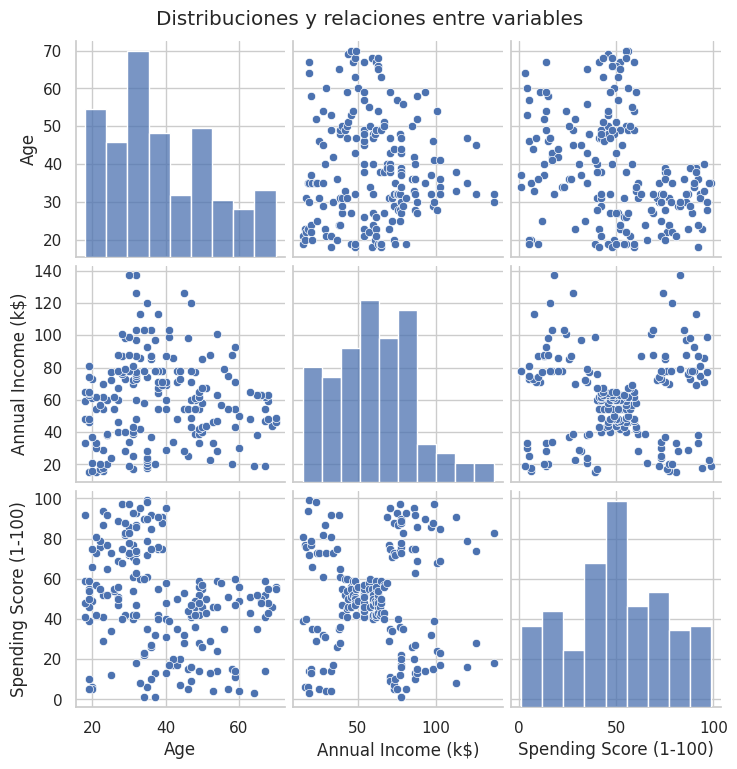

In [46]:
# ---------------------------------------------------------------
# 📊 Visualizar relaciones entre variables numéricas con Seaborn
# ---------------------------------------------------------------

sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
# sns.pairplot() crea una matriz de gráficos de dispersión (scatterplots) entre todas las combinaciones
# posibles de las variables numéricas seleccionadas.
# Cada gráfico muestra cómo se relaciona una variable con otra.
# En la diagonal principal se muestran histogramas o distribuciones de cada variable individualmente.

# Parámetros:
# df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
# → selecciona del DataFrame `df` solo las tres columnas indicadas:
#   - 'Age' → edad de los clientes
#   - 'Annual Income (k$)' → ingreso anual en miles de dólares
#   - 'Spending Score (1-100)' → puntaje de gasto (nivel de consumo del cliente)
# Estas variables son numéricas y se usarán para analizar correlaciones visuales.

plt.suptitle('Distribuciones y relaciones entre variables', y=1.02)
# plt.suptitle() agrega un título general a toda la figura (no a cada subgráfico).
# 'y=1.02' eleva el título un poco por encima del gráfico para evitar que se superponga con los subgráficos.

plt.show()
# plt.show() muestra la figura generada en pantalla.
# Es necesario para visualizar los gráficos en la mayoría de entornos (como scripts de Python o notebooks).


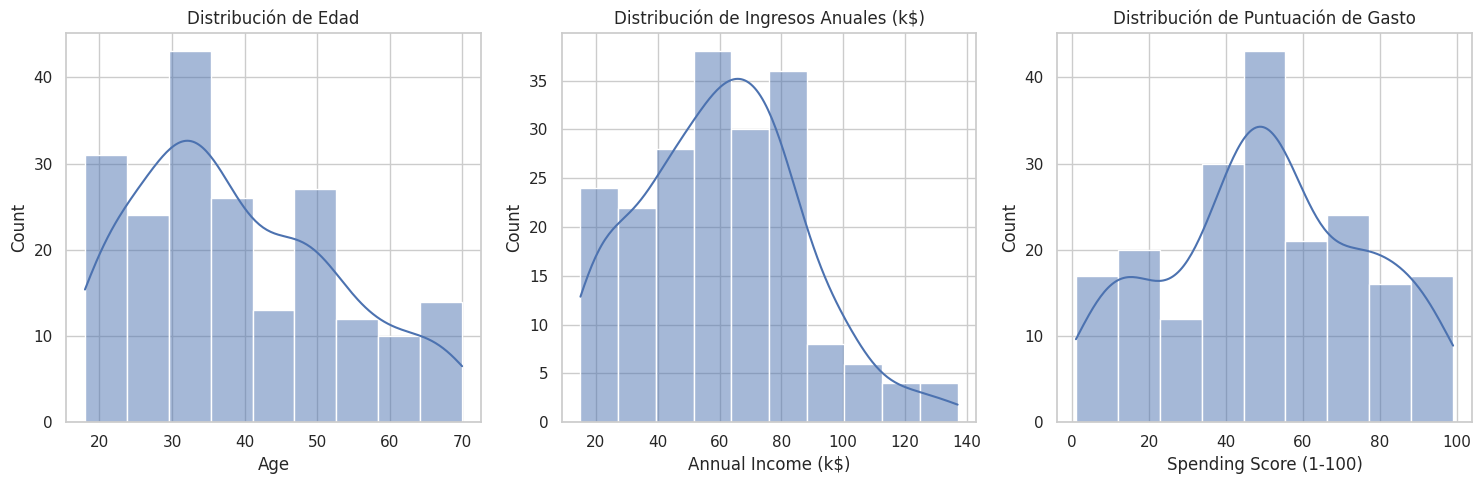

✅ Análisis exploratorio de datos completado.


In [47]:
# ---------------------------------------------------------------
# 📊 Visualización de la distribución de las variables clave
# ---------------------------------------------------------------

plt.figure(figsize=(15, 5))
# Crea una nueva figura con un tamaño de 15 pulgadas de ancho por 5 de alto.
# Esto permite que los tres gráficos (subplots) que haremos se vean grandes y no amontonados.

# ---------------------------------------------------------------
# 🧓 Subgráfico 1: Distribución de la edad
# ---------------------------------------------------------------
plt.subplot(1, 3, 1)
# Crea el primer subgráfico dentro de una cuadrícula de 1 fila y 3 columnas.
# El número 1 indica que este será el primer gráfico (de izquierda a derecha).

sns.histplot(df['Age'], kde=True)
# Dibuja un histograma de la columna "Age" del DataFrame `df`.
# Un histograma muestra la frecuencia (cuántas veces ocurre) de distintos rangos de edad.
# El parámetro `kde=True` agrega una línea de densidad suavizada (Kernel Density Estimation),
# que muestra una curva continua para visualizar la forma general de la distribución.

plt.title('Distribución de Edad')
# Agrega un título al primer subgráfico.

# ---------------------------------------------------------------
# 💰 Subgráfico 2: Distribución del ingreso anual
# ---------------------------------------------------------------
plt.subplot(1, 3, 2)
# Crea el segundo subgráfico en la misma figura (posición 2 de 3).

sns.histplot(df['Annual Income (k$)'], kde=True)
# Dibuja un histograma de la variable "Annual Income (k$)" (ingreso anual en miles de dólares).
# Permite observar si los ingresos están concentrados en ciertos rangos (por ejemplo, ingresos bajos o altos).

plt.title('Distribución de Ingresos Anuales (k$)')
# Agrega título descriptivo a este subgráfico.

# ---------------------------------------------------------------
# 💳 Subgráfico 3: Distribución del puntaje de gasto
# ---------------------------------------------------------------
plt.subplot(1, 3, 3)
# Crea el tercer subgráfico de la figura.

sns.histplot(df['Spending Score (1-100)'], kde=True)
# Dibuja un histograma de la variable "Spending Score (1-100)".
# Esta variable suele representar el comportamiento de compra o gasto de los clientes.
# El KDE muestra si hay grupos de clientes que gastan poco, medio o mucho.

plt.title('Distribución de Puntuación de Gasto')
# Agrega título al tercer gráfico.

# ---------------------------------------------------------------
# 🧩 Ajustes finales del diseño
# ---------------------------------------------------------------
plt.tight_layout()
# Ajusta automáticamente los márgenes y espacios entre subgráficos para evitar que los textos o títulos se sobrepongan.

plt.show()
# Muestra la figura con los tres histogramas.

# ---------------------------------------------------------------
# ✅ Mensaje de confirmación
# ---------------------------------------------------------------
print("✅ Análisis exploratorio de datos completado.")
# Muestra un mensaje en consola indicando que la visualización y análisis se realizaron correctamente.


# ===============================================
# 📌 4. Limpieza de datos
# ===============================================

In [48]:
# Verificamos valores nulos
print(df.isnull().sum())

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [49]:
# Eliminamos la columna 'CustomerID' ya que no aporta al análisis
df_clean = df.drop(['CustomerID'], axis=1)

In [50]:
# ---------------------------------------------------------------
# 🔢 Conversión de variable categórica 'Gender' a variable numérica
# ---------------------------------------------------------------

df_clean = pd.get_dummies(df_clean, drop_first=True)
# Esta función convierte automáticamente las variables categóricas (de texto) del DataFrame `df_clean`
# en variables numéricas mediante el método "One-Hot Encoding".
#
# 👉 One-Hot Encoding:
#    - Toma una columna con categorías de texto (por ejemplo, 'Gender' con valores 'Male' y 'Female')
#    - Crea una nueva columna binaria (de 0s y 1s) para cada categoría.
#
# Ejemplo:
#    Si tenemos:
#       Gender
#       -------
#       Male
#       Female
#       Male
#
#    Al aplicar pd.get_dummies(df_clean), se obtiene:
#       Gender_Female   Gender_Male
#       --------------  -----------
#       0               1
#       1               0
#       0               1
#
# ⚙️ Parámetro:
#    - drop_first=True → elimina la primera categoría (por ejemplo, 'Gender_Male')
#      para evitar la *trampa de la multicolinealidad* (cuando una variable puede
#      deducirse de las otras, lo que causa problemas en modelos lineales).
#
# Resultado:
#    - El DataFrame `df_clean` ahora solo contiene valores numéricos,
#      listos para usarse en modelos de Machine Learning.


In [51]:
# Resultado
df_clean.head()

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
0,19,15,39,True
1,21,15,81,True
2,20,16,6,False
3,23,16,77,False
4,31,17,40,False


# ===============================================
# 📌 5. Normalización de los datos
# ===============================================

🔄 **¿Por qué normalizamos los datos?**

K-means calcula distancias entre puntos. Si usamos valores sin escalar (ej. edad vs ingresos), una variable dominará la otra.  
La normalización pone todos los valores en la **misma escala (media=0, desviación estándar=1)** para que todas las variables tengan el mismo peso en la segmentación.


In [52]:
# ---------------------------------------------------------------
# ⚖️ Estandarización de las variables numéricas
# ---------------------------------------------------------------

scaler = StandardScaler()
# Crea un objeto de la clase StandardScaler del módulo sklearn.preprocessing.
# Este objeto se encargará de escalar (normalizar) las variables numéricas del DataFrame.
#
# ¿Por qué escalar?
# En muchos algoritmos de Machine Learning (como K-Means, Regresión Logística o PCA),
# las variables con valores más grandes pueden "dominar" las demás.
# Por ejemplo, si una variable mide ingresos en miles y otra edad en años,
# el ingreso tiene una escala mucho mayor y puede sesgar el resultado.
#
# La estandarización convierte todas las variables para que:
#   - Tengan media (promedio) = 0
#   - Tengan desviación estándar = 1
#
# Fórmula:
#   X_esc = (X - media) / desviación_estándar

df_scaled = scaler.fit_transform(df_clean)
# Aplica la estandarización a todas las columnas numéricas del DataFrame `df_clean`.
# - fit() calcula la media y desviación estándar de cada variable.
# - transform() aplica la transformación a los datos.
# - fit_transform() combina ambos pasos en uno solo.
#
# El resultado `df_scaled` es un arreglo NumPy (no un DataFrame) con los valores escalados.
# Cada columna tiene media 0 y desviación estándar 1.

# ---------------------------------------------------------------
# 🔍 Verificación de la transformación
# ---------------------------------------------------------------

print("Media:", df_scaled.mean(axis=0))
# Calcula y muestra la media de los valores escalados (por columnas).
# Debería ser aproximadamente 0 para cada variable, si la estandarización fue correcta.

print("Desviación estándar:", df_scaled.std(axis=0))
# Calcula y muestra la desviación estándar de los valores escalados (por columnas).
# Debería ser aproximadamente 1 para todas las variables.


Media: [-1.02140518e-16 -2.13162821e-16 -1.46549439e-16  3.10862447e-17]
Desviación estándar: [1. 1. 1. 1.]


✅ Media ~ 0
La media de cada columna (variable) ha sido transformada para que sea prácticamente cero.
Esos valores muy pequeños como -1e-16 o 3e-17 son numéricamente cercanos a cero, con pequeñas diferencias por redondeo y precisión numérica en coma flotante.

🔹 Ejemplo: -1.02140518e-16 ≈ 0

✅ Desviación estándar = 1
Cada variable ahora tiene varianza 1, es decir, han sido "normalizadas" para tener la misma escala de dispersión.

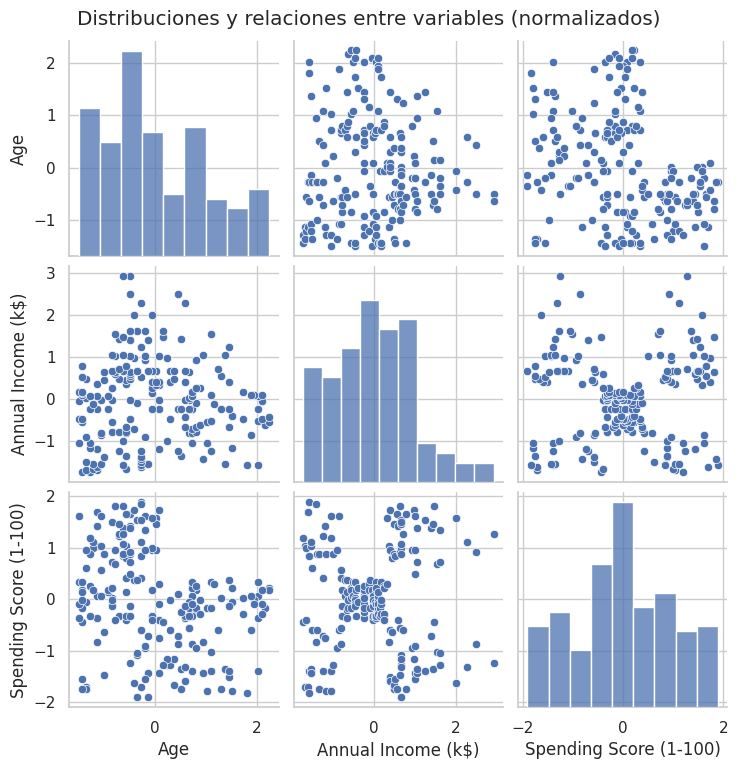

In [53]:
# ---------------------------------------------------------------
# 🔄 Convertir el array escalado nuevamente a un DataFrame
# ---------------------------------------------------------------

df_scaled = pd.DataFrame(df_scaled, columns=df_clean.columns)
# La función pd.DataFrame() convierte el arreglo NumPy `df_scaled` (resultado de StandardScaler)
# en un DataFrame de pandas.
#
# Parámetros:
#   - df_scaled → los valores numéricos ya estandarizados (media = 0, desviación estándar = 1)
#   - columns=df_clean.columns → usa los mismos nombres de columnas que tenía el DataFrame original `df_clean`
#
# Resultado:
#   - Ahora `df_scaled` es un DataFrame de pandas con los mismos nombres de variables,
#     pero con valores escalados.

# ---------------------------------------------------------------
# 🎯 Selección de las variables numéricas principales
# ---------------------------------------------------------------

df_scaled = pd.DataFrame(df_scaled[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
# De todas las columnas del DataFrame escalado, seleccionamos solo tres:
#   - 'Age' → edad del cliente
#   - 'Annual Income (k$)' → ingreso anual en miles de dólares
#   - 'Spending Score (1-100)' → nivel de gasto o consumo
#
# Esto se hace porque estas tres variables son las más relevantes para el análisis
# y se quieren visualizar en un gráfico comparativo.
#
# Se crea un nuevo DataFrame (también llamado df_scaled) solo con esas columnas.

# ---------------------------------------------------------------
# 📊 Visualización: relaciones entre variables normalizadas
# ---------------------------------------------------------------

sns.pairplot(df_scaled)
# Crea una matriz de gráficos (pairplot) que muestra:
#   - En la diagonal → histogramas o distribuciones de cada variable.
#   - Fuera de la diagonal → gráficos de dispersión (scatterplots) entre pares de variables.
#
# Dado que los datos están normalizados, todas las variables están en la misma escala,
# lo que facilita comparar tendencias o correlaciones.

plt.suptitle('Distribuciones y relaciones entre variables (normalizados)', y=1.02)
# Agrega un título general a todo el conjunto de subgráficos.
# El parámetro 'y=1.02' ajusta la posición vertical del título (ligeramente por encima de los gráficos).

plt.show()
# Muestra en pantalla la figura generada con Seaborn y Matplotlib.



📊 1. Distribuciones individuales (diagonal)
Age (Edad): Distribución sesgada a la izquierda (más clientes jóvenes que mayores).

Annual Income (Ingresos): Distribución más uniforme pero con ligera concentración entre -1 y 1.

Spending Score: Presenta una distribución casi simétrica, aunque se observan clientes con puntajes extremos.

Todas las variables tienen centro en 0 y rango típico entre -2 y 2 → ✅ Normalización exitosa.


# ===============================================
# 📌 6. Segmentación de datos (70% train, 15% val, 15% test)
# ===============================================

In [54]:
# Usamos train_test_split para crear subconjuntos de entrenamiento, validación y prueba
X_train, X_temp = train_test_split(df_scaled, test_size=0.30, random_state=42)
X_val, X_test = train_test_split(X_temp, test_size=0.50, random_state=42)

print(f'Tamaño del conjunto de entrenamiento: {len(X_train)}')
print(f'Tamaño del conjunto de validación: {len(X_val)}')
print(f'Tamaño del conjunto de prueba: {len(X_test)}')

Tamaño del conjunto de entrenamiento: 140
Tamaño del conjunto de validación: 30
Tamaño del conjunto de prueba: 30


# ===============================================
# 📌 7. Determinar número óptimo de clusters (método del codo)
# ===============================================

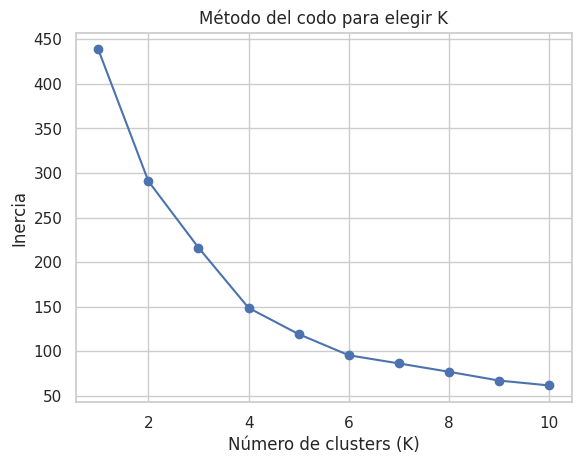

In [55]:
# ---------------------------------------------------------------
# 💡 Método del codo para elegir el número óptimo de clusters (K)
# ---------------------------------------------------------------

inertia = []
# Creamos una lista vacía para almacenar la inercia de cada modelo KMeans.
# La inercia mide la suma de las distancias cuadradas de cada punto a su centroide.
# Valores más bajos indican clusters más compactos.

K = range(1, 11)
# Definimos un rango de posibles valores de K (1 a 10 clusters) para probar.
# El objetivo es encontrar el "codo" en la curva donde agregar más clusters ya no reduce significativamente la inercia.
# Inercia (medida de cuán compactos están los clusters)

# ---------------------------------------------------------------
# 🔄 Iteramos sobre los valores de K
# ---------------------------------------------------------------
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Creamos un modelo KMeans con:
    #   - n_clusters=k → número de clusters a generar
    #   - random_state=42 → semilla para resultados reproducibles
    #   - n_init=10 → número de veces que el algoritmo KMeans se inicializa con centroides diferentes;
    #     se toma la mejor solución (la que minimiza la inercia)

    kmeans.fit(X_train)
    # Entrenamos el modelo con los datos de entrenamiento `X_train`.
    # El algoritmo asigna cada punto a un cluster y ajusta los centroides para minimizar la inercia.

    inertia.append(kmeans.inertia_)
    # Guardamos el valor de la inercia para este número de clusters.
    # kmeans.inertia_ es la suma de distancias cuadradas de cada punto a su centroide.

# ---------------------------------------------------------------
# 📈 Visualización del método del codo
# ---------------------------------------------------------------
plt.plot(K, inertia, 'bo-')
# 'bo-' → círculos azules ('b') conectados por línea continua ('-')
# El eje X representa el número de clusters (K)
# El eje Y representa la inercia correspondiente a cada K

plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del codo para elegir K')
plt.show()
# Muestra la gráfica en pantalla
# El "codo" en la curva indica el K óptimo:
#   - Antes del codo: agregar clusters reduce mucho la inercia
#   - Después del codo: agregar más clusters apenas mejora la inercia (posible sobreajuste)


# ===============================================
# 📌 8. Entrenamiento del modelo K-means
# ===============================================

In [56]:
# ---------------------------------------------------------------
# 🔹 Definir el número óptimo de clusters
# ---------------------------------------------------------------

# Suponemos que el mejor K, determinado visualmente con el método del codo, es 5
# En este caso, se está usando 4 como ejemplo:
k_optimo = 5
# k_optimo → número de clusters que vamos a usar para entrenar el modelo KMeans.
# Este valor se suele elegir observando la gráfica del codo.

# ---------------------------------------------------------------
# 🔹 Entrenar el modelo KMeans
# ---------------------------------------------------------------

kmeans = KMeans(
    n_clusters=k_optimo,   # Número de clusters a crear
    random_state=42,       # Semilla aleatoria para reproducibilidad
    n_init=10              # Número de inicializaciones diferentes para evitar mínimos locales
)
kmeans.fit(X_train)
# Ajusta el modelo KMeans a los datos de entrenamiento `X_train`.
# El algoritmo encuentra los centroides de los clusters y asigna cada punto al cluster más cercano.
# Después de entrenar:
#   - kmeans.cluster_centers_ → contiene las coordenadas de los centroides
#   - kmeans.labels_ → etiquetas de cada punto del entrenamiento


KMeans(n_clusters=5, n_init=10, random_state=42)

In [57]:
# 🔹 Asignar clusters a los datos de test
test_labels = kmeans.predict(X_test)
# Predice a qué cluster pertenece cada punto del conjunto de prueba `X_test`.

In [58]:
# ---------------------------------------------------------------
# 🔹 Asignar clusters a los datos de validación
# ---------------------------------------------------------------

val_labels = kmeans.predict(X_val)
# Predice a qué cluster pertenece cada punto del conjunto de validación `X_val`.
# val_labels → arreglo con números enteros [0, k_optimo-1] que representan la etiqueta de cluster asignada a cada dato.

# ===============================================
# 📌 9. Evaluación del modelo con Silhouette Score
# ===============================================

In [59]:
# ---------------------------------------------------------------
# 🔹 Calcular el Silhouette Score para los clusters de test
# ---------------------------------------------------------------

score_test = silhouette_score(X_test, test_labels)
# silhouette_score() es una función de sklearn.metrics que mide qué tan bien definidos y separados están los clusters.
#
# Parámetros:
#   - X_val → los datos de prueba (en este caso, normalizados/escalados)
#   - val_test → etiquetas de cluster asignadas por el modelo KMeans
#
# Concepto:
#   - Para cada punto, el Silhouette Score combina:
#       a) la distancia media entre el punto y los otros puntos del mismo cluster (cohesión)
#       b) la distancia media entre el punto y los puntos del cluster más cercano (separación)
#   - Fórmula simplificada:
#       s = (b - a) / max(a, b)
#       donde a = promedio de distancias dentro del mismo cluster, b = promedio de distancias al cluster más cercano
#
# Interpretación del valor:
#   - Rango: [-1, 1]
#   - s ≈ 1 → cluster bien definido, punto dentro de su cluster
#   - s ≈ 0 → punto entre clusters
#   - s < 0 → punto mal asignado (más cerca de otro cluster)
#   - Generalmente, un valor promedio > 0.5 indica clusters claramente separados.

# ---------------------------------------------------------------
# 🔹 Mostrar el resultado
# ---------------------------------------------------------------
print(f'Silhouette Score en validación: {score_test:.2f}')
# Imprime el Silhouette Score en consola, redondeado a 2 decimales.
# Permite evaluar la calidad del clustering obtenido en los datos de validación.


Silhouette Score en validación: 0.43


In [60]:
# ---------------------------------------------------------------
# 🔹 Calcular el Silhouette Score para los clusters de validación
# ---------------------------------------------------------------

score_val = silhouette_score(X_val, val_labels)
# silhouette_score() es una función de sklearn.metrics que mide qué tan bien definidos y separados están los clusters.
#
# Parámetros:
#   - X_val → los datos de validación (en este caso, normalizados/escalados)
#   - val_labels → etiquetas de cluster asignadas por el modelo KMeans
#
# Concepto:
#   - Para cada punto, el Silhouette Score combina:
#       a) la distancia media entre el punto y los otros puntos del mismo cluster (cohesión)
#       b) la distancia media entre el punto y los puntos del cluster más cercano (separación)
#   - Fórmula simplificada:
#       s = (b - a) / max(a, b)
#       donde a = promedio de distancias dentro del mismo cluster, b = promedio de distancias al cluster más cercano
#
# Interpretación del valor:
#   - Rango: [-1, 1]
#   - s ≈ 1 → cluster bien definido, punto dentro de su cluster
#   - s ≈ 0 → punto entre clusters
#   - s < 0 → punto mal asignado (más cerca de otro cluster)
#   - Generalmente, un valor promedio > 0.5 indica clusters claramente separados.

# ---------------------------------------------------------------
# 🔹 Mostrar el resultado
# ---------------------------------------------------------------
print(f'Silhouette Score en validación: {score_val:.2f}')
# Imprime el Silhouette Score en consola, redondeado a 2 decimales.
# Permite evaluar la calidad del clustering obtenido en los datos de validación.


Silhouette Score en validación: 0.35


| Rango del Silhouette Score | Interpretación general               |
| -------------------------- | ------------------------------------ |
| 0.71 – 1.00                | Clustering fuerte                    |
| 0.51 – 0.70                | Clustering razonable                 |
| 0.26 – 0.50                | Estructura débil, pero detectable    |
| **0.00 – 0.25**            | **Clustering muy débil o aleatorio** |


# ===============================================
# 📌 10. Visualización de clusters con PCA (reducción a 2D)
# ===============================================

In [61]:
# ---------------------------------------------------------------
# 🔹 Reducción de dimensionalidad con PCA para visualización
# ---------------------------------------------------------------

pca = PCA(n_components=2)
# Creamos un objeto PCA (Principal Component Analysis) para reducir la dimensionalidad de los datos.
# n_components=2 → queremos reducir los datos a 2 dimensiones, para poder graficarlos en un plano XY.
# PCA transforma los datos originales en nuevas variables ortogonales llamadas "componentes principales",
# que capturan la mayor varianza posible de los datos.

X_pca = pca.fit_transform(df_scaled)

# Mostrar cuánta información conserva cada componente
print("Varianza explicada:")
print(pca.explained_variance_ratio_)


Varianza explicada:
[0.44266167 0.33308378]


In [62]:
# ---------------------------------------------------------------
# 🔹 Predecir clusters finales para todo el DataFrame escalado
# ---------------------------------------------------------------

cluster_labels = kmeans.predict(df_scaled)
# Usamos el modelo KMeans ya entrenado para asignar un cluster a cada punto de `df_scaled`.
# Resultado: un array de etiquetas [0, k_optimo-1] que indica a qué cluster pertenece cada dato.

# ---------------------------------------------------------------
# 🔹 Agregar los resultados de clustering al DataFrame original
# ---------------------------------------------------------------

df_clean['Cluster'] = cluster_labels
# Creamos una nueva columna 'Cluster' en `df_clean` que almacena la etiqueta de cluster de cada registro.
# Esto permite:
#   - Analizar estadísticas por cluster
#   - Visualizar clusters con gráficos
#   - Combinar con otras variables categóricas o numéricas

# Imprimir resultados con asignación de cluster
df_clean.head()

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,Cluster
0,19,15,39,True,3
1,21,15,81,True,3
2,20,16,6,False,4
3,23,16,77,False,3
4,31,17,40,False,3


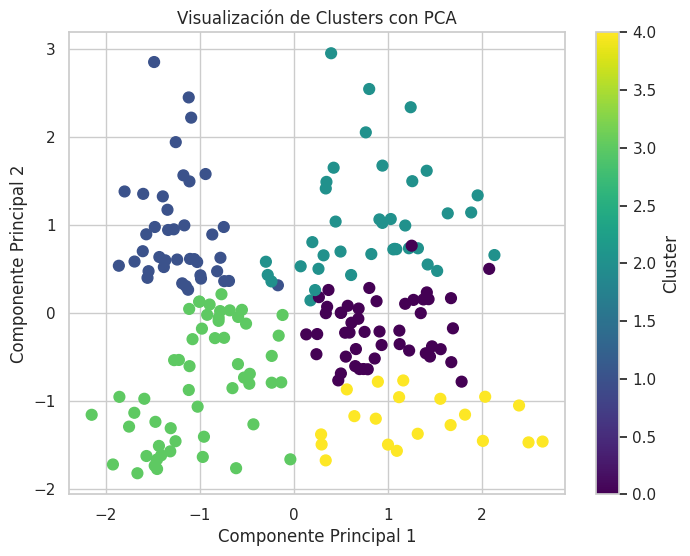

In [63]:
# ---------------------------------------------------------------
# Gráfico de los clusters utilizando PCA
# ---------------------------------------------------------------

plt.figure(figsize=(8,6))
# Crea una nueva figura donde se mostrará el gráfico.
# figsize=(8,6) indica el tamaño de la figura:
# 8 pulgadas de ancho y 6 pulgadas de alto.

plt.scatter(
    X_pca[:,0],          # Eje X: Primer Componente Principal (PC1)
    X_pca[:,1],          # Eje Y: Segundo Componente Principal (PC2)
    c=cluster_labels,    # Asigna un color diferente a cada cluster.
    cmap="viridis",      # Paleta de colores utilizada para distinguir los clusters.
    s=60                 # Tamaño de cada punto del gráfico.
)

# Etiqueta del eje X
plt.xlabel("Componente Principal 1")
# Representa el componente que conserva la mayor cantidad de información
# (mayor varianza) del conjunto de datos.

# Etiqueta del eje Y
plt.ylabel("Componente Principal 2")
# Representa el segundo componente principal,
# que conserva la mayor información restante.

# Título del gráfico
plt.title("Visualización de Clusters con PCA")
# Describe el contenido del gráfico.

# Agrega una barra de colores
plt.colorbar(label="Cluster")
# Muestra qué color corresponde a cada cluster asignado por K-Means.

# Agrega una cuadrícula para facilitar la lectura
plt.grid(True)

# Muestra el gráfico en pantalla
plt.show()

In [64]:
# ==============================================================
# 🏷️ ETIQUETADO DE SEGMENTOS SEGÚN PERFIL
# ==============================================================

# ---------------------------------------------------------------
# 🔹 Analizar características promedio por cluster
# ---------------------------------------------------------------

cluster_summary = df_clean.groupby('Cluster').mean(numeric_only=True)
# df_clean.groupby('Cluster') → agrupa los datos por la columna 'Cluster'.
# .mean(numeric_only=True) → calcula la media de las variables numéricas para cada cluster.
#
# Resultado:
#   - Un DataFrame donde cada fila representa un cluster
#   - Cada columna muestra la media de esa variable dentro del cluster
#   - Permite identificar patrones: edad promedio, ingreso promedio, gasto promedio, etc.

display(cluster_summary)
# Muestra el resumen de manera visual (especialmente útil en Jupyter Notebook o entornos interactivos)
# para poder inspeccionar rápidamente los perfiles de cada cluster.

# ---------------------------------------------------------------
# 🔹 Asignar etiquetas descriptivas a los clusters
# ---------------------------------------------------------------

nombres_segmentos = {
    0: "Clientes conservadores",
    1: "Compradores impulsivos",
    2: "Clientes premium activos",
    3: "Clientes cautelosos",
    4: "Potencial no explotado"
}
# Creamos un diccionario que asigna un nombre descriptivo a cada cluster.
# Claves → número del cluster (0,1,2,3,4)
# Valores → nombre del segmento basado en análisis de medias y comportamiento del cliente

df_clean['Segmento'] = df_clean['Cluster'].map(nombres_segmentos)
# Usamos .map() para reemplazar cada etiqueta numérica de cluster con su nombre descriptivo.
# Resultado:
#   - Nueva columna 'Segmento' en df_clean
#   - Permite trabajar con etiquetas comprensibles y no solo números
#   - Facilita análisis y visualización de perfiles de clientes

# Imprimir resultados con asignación de cluster
df_clean.head()

,Age,Annual Income (k$),Spending Score (1-100),Genre_Male
Cluster,,,,
0,55.708333,54.729167,48.062500,0.437500
1,32.875000,86.100000,81.525000,0.450000
2,39.368421,86.500000,19.578947,0.500000
3,25.185185,41.092593,62.240741,0.407407
4,46.250000,26.750000,18.350000,0.400000


,Age,Annual Income (k$),Spending Score (1-100),Genre_Male,Cluster,Segmento
0,19,15,39,True,3,Clientes cautelosos
1,21,15,81,True,3,Clientes cautelosos
2,20,16,6,False,4,Potencial no explotado
3,23,16,77,False,3,Clientes cautelosos
4,31,17,40,False,3,Clientes cautelosos


In [65]:
# ==============================================================
# 🧠 ANÁLISIS DE NEGOCIO
# ==============================================================

# ---------------------------------------------------------------
# 🔹 Conteo de clientes por segmento
# ---------------------------------------------------------------

conteo_segmentos = df_clean['Segmento'].value_counts()
# df_clean['Segmento'] → accede a la columna que contiene las etiquetas descriptivas de cada cluster.
# .value_counts() → cuenta cuántas veces aparece cada etiqueta en la columna.
#
# Resultado:
#   - Un objeto pandas Series donde:
#       - índice → nombre del segmento
#       - valor → número de clientes en ese segmento
#   - Permite conocer la distribución de clientes entre los distintos perfiles identificados.

# ---------------------------------------------------------------
# 🔹 Mostrar resultados en consola
# ---------------------------------------------------------------
print("Distribución de clientes por segmento:\n")
print(conteo_segmentos)
# Imprime en pantalla la cantidad de clientes en cada segmento
# Útil para identificar:
#   - Segmentos más grandes o dominantes
#   - Segmentos pequeños o nichos
#   - Potencial de enfoque de marketing o estrategia de negocio


Distribución de clientes por segmento:

Segmento
Clientes cautelosos         54
Clientes conservadores      48
Compradores impulsivos      40
Clientes premium activos    38
Potencial no explotado      20
Name: count, dtype: int64


##Exportar resultados a Excel

In [66]:
# Exportamos el dataframe con segmentos a Excel (requiere openpyxl instalado)
df_clean.to_excel('/content/Clientes_Segmentados.xlsx', index=False)

print("✅ Archivo exportado como Clientes_Segmentados.xlsx")


✅ Archivo exportado como Clientes_Segmentados.xlsx
